In [ ]:
! pip install wfdb neurokit2 numpy pandas scikit-learn matplotlib tensorflow scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 112.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import os
import wfdb
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import butter, filtfilt

def bandpass_filter(sig, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    # Ensure lowcut and highcut are within valid normalized frequency range (0, 1)
    # and that lowcut < highcut after normalization.
    # If highcut is at or above Nyquist, adjust it slightly below.
    if highcut >= nyq: highcut = nyq - 0.01
    # If lowcut is at or above Nyquist, or higher than adjusted highcut, it's an invalid range.
    if lowcut >= nyq or lowcut >= highcut: # Added check to prevent Wn[0] >= Wn[1] or Wn[0] >= 1
        # Handle this case, e.g., by returning an unfiltered signal or raising an error
        # For now, let's assume we want to skip filtering or use a sensible default
        print(f"Warning: Invalid filter parameters (lowcut={lowcut}, highcut={highcut}, fs={fs}). Skipping bandpass filter for this segment.")
        return sig # Return original signal if filter parameters are nonsensical

    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype="band")
    return filtfilt(b, a, sig)

folder = "/content/drive/MyDrive/bidmc-ppg-and-respiration-dataset-1.0.0"  # Replace with your folder path
recordings = [f.split(".")[0] for f in os.listdir(folder) if f.lower().endswith(".hea")]
print("Found recordings:", recordings)

all_signals = {}

for rec_name in recordings:
    record = wfdb.rdrecord(os.path.join(folder, rec_name))
    # Ensure fs is a reasonable value; default to 125 Hz if record.fs is None, 0, or too low
    fs = record.fs if (record.fs is not None and record.fs > 50) else 125 # Changed line

    ecg = record.p_signal[:,0]      # ECG
    resp = record.p_signal[:,1]     # Respiration

    # Filter ECG
    ecg_clean = bandpass_filter(ecg, lowcut=0.5, highcut=40, fs=fs)
    ecg_clean = MinMaxScaler().fit_transform(ecg_clean.reshape(-1,1)).flatten()

    # Normalize Respiration
    resp_clean = MinMaxScaler().fit_transform(resp.reshape(-1,1)).flatten()

    # Store only ECG + Resp
    all_signals[rec_name] = np.vstack([ecg_clean, resp_clean]).T

Found recordings: ['bidmc29n', 'bidmc15', 'bidmc15n', 'bidmc19', 'bidmc08', 'bidmc52', 'bidmc12n', 'bidmc40', 'bidmc22n', 'bidmc52n', 'bidmc44n', 'bidmc45', 'bidmc53', 'bidmc09n', 'bidmc35', 'bidmc31n', 'bidmc51n', 'bidmc34', 'bidmc36n', 'bidmc32n', 'bidmc07', 'bidmc38', 'bidmc45n', 'bidmc44', 'bidmc17n', 'bidmc35n', 'bidmc48n', 'bidmc10', 'bidmc29', 'bidmc22', 'bidmc05', 'bidmc34n', 'bidmc33', 'bidmc23n', 'bidmc36', 'bidmc48', 'bidmc42n', 'bidmc14n', 'bidmc03', 'bidmc49', 'bidmc53n', 'bidmc50', 'bidmc07n', 'bidmc16', 'bidmc20n', 'bidmc37', 'bidmc40n', 'bidmc31', 'bidmc30n', 'bidmc01', 'bidmc49n', 'bidmc25', 'bidmc24n', 'bidmc38n', 'bidmc06', 'bidmc46', 'bidmc41', 'bidmc37n', 'bidmc27n', 'bidmc18', 'bidmc19n', 'bidmc24', 'bidmc04', 'bidmc41n', 'bidmc28', 'bidmc42', 'bidmc46n', 'bidmc11', 'bidmc09', 'bidmc25n', 'bidmc43', 'bidmc39n', 'bidmc20', 'bidmc06n', 'bidmc50n', 'bidmc13', 'bidmc47', 'bidmc13n', 'bidmc10n', 'bidmc08n', 'bidmc02n', 'bidmc11n', 'bidmc26n', 'bidmc05n', 'bidmc30', 'bi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [ ]:
def segment_signal(signal, window_size, step_size):
    """
    Segment 2D signal (samples x channels) into overlapping windows.
    - signal: np.array of shape (num_samples, num_channels)
    - window_size: number of samples per window
    - step_size: number of samples to move for next window
    Returns: list of windows (numpy arrays)
    """
    segments = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        segments.append(signal[start:end])
    return np.array(segments)


In [ ]:
fs = 125
window_size = 5 * fs
step_size = int(2.5 * fs)  # 50% overlap


In [ ]:
X_all = []  # Segmented windows
record_names = []  # Keep track of recording for reference

for rec_name, signal in all_signals.items():
    segments = segment_signal(signal, window_size, step_size)
    X_all.extend(segments)
    record_names.extend([rec_name]*len(segments))

X_all = np.array(X_all)
print("Total windows:", X_all.shape)


Total windows: (10123, 625, 2)


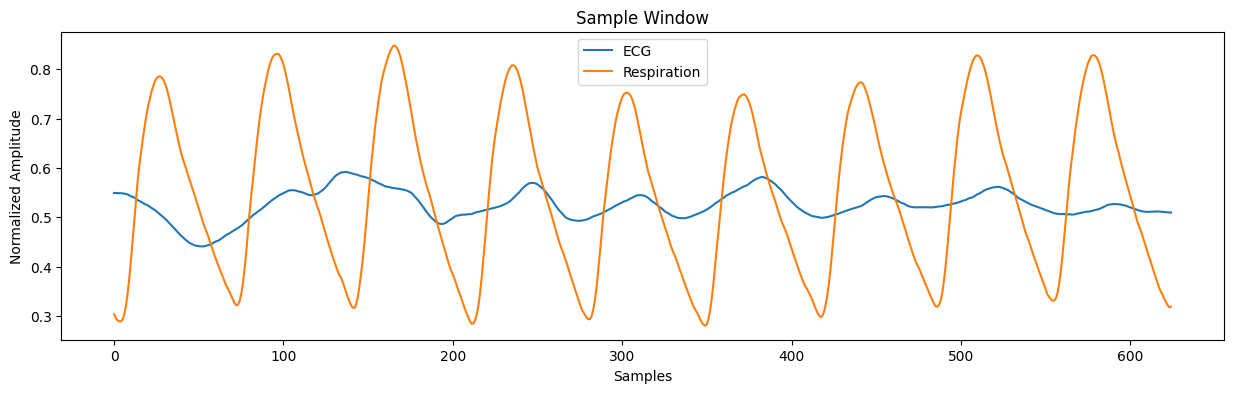

In [ ]:
import matplotlib.pyplot as plt

window_to_plot = X_all[0]

plt.figure(figsize=(15,4))
plt.plot(window_to_plot[:,0], label="ECG")
plt.plot(window_to_plot[:,1], label="Respiration")
plt.title("Sample Window")
plt.xlabel("Samples")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# Encode subject labels
le = LabelEncoder()
y_all = le.fit_transform(record_names)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (8098, 625, 2) Test shape: (2025, 625, 2)


In [ ]:
def build_cnn_lstm(input_shape, num_classes):
    model = models.Sequential()

    # --- CNN layers (local feature extraction) ---
    model.add(layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Conv1D(64, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Dropout(0.3))

    # --- LSTM layers (sequential dependency learning) ---
    model.add(layers.LSTM(64, return_sequences=False))

    # --- Fully connected ---
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])  # (window_size, channels)
num_classes = len(np.unique(y_all))
model = build_cnn_lstm(input_shape, num_classes)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 621, 32)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 310, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 306, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 153, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 153, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 53)             │         3,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,285 (200.33 KB)

 Trainable params: 51,285 (200.33 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)


Epoch 1/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7047 - loss: 0.9074 - val_accuracy: 0.7560 - val_loss: 0.7967
Epoch 2/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7458 - loss: 0.8038 - val_accuracy: 0.7659 - val_loss: 0.7398
Epoch 3/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7321 - loss: 0.8297 - val_accuracy: 0.6721 - val_loss: 0.9793
Epoch 4/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7513 - loss: 0.7748 - val_accuracy: 0.7901 - val_loss: 0.7373
Epoch 5/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7578 - loss: 0.7412 - val_accuracy: 0.8336 - val_loss: 0.6294
Epoch 6/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7943 - loss: 0.6370 - val_accuracy: 0.8257 - val_loss: 0.6162
Epoch 7/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7891 - loss: 0.6227 - val_accuracy: 0.7753 - val_loss: 0.7083
Epoch 8/30
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7773 - loss: 0.6884 - val_accu

In [ ]:
model.save("ecg_resp_cnn_lstm.keras")   # ✅ recommended
np.save("/content/ecg_resp_cnn_lstm.npy", le.classes_) # Save label classes

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9195 - loss: 0.2697
Test Accuracy: 91.51%


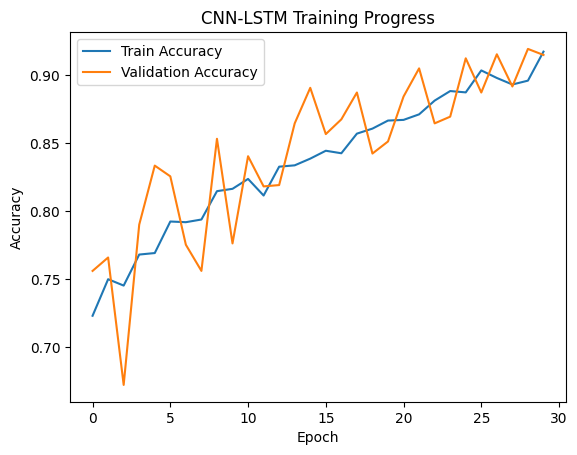

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN-LSTM Training Progress")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
from tensorflow import keras

# Load the trained CNN-LSTM model
model = keras.models.load_model("/content/ecg_resp_cnn_lstm.keras")

# Load label classes
label_classes = np.load("/content/ecg_resp_cnn_lstm.npy", allow_pickle=True)



In [ ]:
import wfdb
import neurokit2 as nk
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def preprocess_hea_for_cnn_lstm(file_path):
    """
    Takes a .hea file path and returns a 3D array suitable for CNN-LSTM prediction
    """
    record_name = file_path.replace(".hea", "")
    record = wfdb.rdrecord(record_name)

    # Extract ECG and Resp signals
    ecg = record.p_signal[:, 0]
    resp = record.p_signal[:, 1]
    fs = record.fs

    # Clean signals
    ecg_clean = nk.ecg_clean(ecg, sampling_rate=fs)
    resp_clean = nk.rsp_clean(resp, sampling_rate=fs)

    # Normalize
    ecg_clean = MinMaxScaler().fit_transform(ecg_clean.reshape(-1,1)).flatten()
    resp_clean = MinMaxScaler().fit_transform(resp_clean.reshape(-1,1)).flatten()

    # Take first 5-second window
    window_size = int(5 * fs)
    if len(ecg_clean) < window_size:
        raise ValueError("Recording too short for 5s window")

    ecg_window = ecg_clean[:window_size]
    resp_window = resp_clean[:window_size]

    # Combine ECG + Resp as 2-channel input
    features = np.vstack([ecg_window, resp_window]).T  # shape = (window_size, 2)

    # Add batch dimension
    features = features[np.newaxis, :, :]  # shape = (1, window_size, 2)
    return features


In [ ]:
!pip install wfdb numpy pandas scikit-learn matplotlib tensorflow scipy


In [ ]:
# Example .hea file
file_path = "/content/drive/MyDrive/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc01.hea"

# Preprocess
X_test = preprocess_hea_for_cnn_lstm(file_path)

# Predict
pred_probs = model.predict(X_test)
predicted_class = np.argmax(pred_probs, axis=1)[0]

print(f"✅ Predicted Person ID index: {predicted_class}")
print(f"🔹 Confidence: {pred_probs[0][predicted_class]*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
✅ Predicted Person ID index: 0
🔹 Confidence: 71.14%
